# Customer Churn Prediction
### Logistic Regression / Random Forest / Gradient Boosting
Dataset: Bank Customer Churn (10,000 customers, 14 features)

## Imports and Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
%matplotlib inline

DATA_PATH  = r'C:\Users\vinnu\Downloads\Churn_Modelling.csv'
OUTPUT_DIR = r'C:\Users\vinnu\Downloads\CODSOFT\CodSoft_task3_Customer_Churn_Prediction\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports done')

Imports done


## Load and Explore Data

In [2]:
print('Loading data ...')
df = pd.read_csv(DATA_PATH)

print(f'   Total customers  : {len(df):,}')
print(f'   Features         : {df.shape[1]}')
print(f'   Churned          : {df["Exited"].sum():,} ({df["Exited"].mean()*100:.1f}%)')
print(f'   Retained         : {(df["Exited"]==0).sum():,} ({(df["Exited"]==0).mean()*100:.1f}%)')
print(f'   Missing values   : {df.isnull().sum().sum()}')
df.head()

Loading data ...
   Total customers  : 10,000
   Features         : 14
   Churned          : 2,037 (20.4%)
   Retained         : 7,963 (79.6%)
   Missing values   : 0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Preprocessing

In [3]:
# Drop irrelevant columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode categorical features
le_geo    = LabelEncoder()
le_gender = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender']    = le_gender.fit_transform(df['Gender'])

# Features and target
X = df.drop(columns=['Exited'])
y = df['Exited']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (for Logistic Regression)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Preprocessing done')
print(f'   Training samples : {len(X_train):,}')
print(f'   Test samples     : {len(X_test):,}')
print(f'   Features used    : {list(X.columns)}')

Preprocessing done
   Training samples : 8,000
   Test samples     : 2,000
   Features used    : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## Train All Models

In [4]:
from sklearn.metrics import precision_score, recall_score

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, C=1.0), X_train_scaled, X_test_scaled),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1), X_train, X_test),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42), X_train, X_test),
}

results     = {}
predictions = {}
trained     = {}

for name, (clf, Xtr, Xte) in models.items():
    print(f'Training: {name} ...')
    clf.fit(Xtr, y_train)
    preds = clf.predict(Xte)
    predictions[name] = preds
    trained[name]     = (clf, Xte)
    results[name] = {
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1':        f1_score(y_test, preds),
        'ROC-AUC':   roc_auc_score(y_test, clf.predict_proba(Xte)[:,1])
    }
    print(f'   Accuracy: {results[name]["Accuracy"]:.4f}  |  F1: {results[name]["F1"]:.4f}  |  ROC-AUC: {results[name]["ROC-AUC"]:.4f}')

best_name  = max(results, key=lambda k: results[k]['ROC-AUC'])
best_preds = predictions[best_name]
print(f'\nBest model: {best_name}')

Training: Logistic Regression ...
   Accuracy: 0.8050  |  F1: 0.2292  |  ROC-AUC: 0.7710
Training: Random Forest ...
   Accuracy: 0.8640  |  F1: 0.5627  |  ROC-AUC: 0.8596
Training: Gradient Boosting ...
   Accuracy: 0.8640  |  F1: 0.5904  |  ROC-AUC: 0.8633

Best model: Gradient Boosting


## Classification Report

In [5]:
print(f'Classification Report - {best_name}\n')
print(classification_report(y_test, best_preds, target_names=['Retained', 'Churned']))

Classification Report - Gradient Boosting

              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



## Graph 1: Churn Distribution

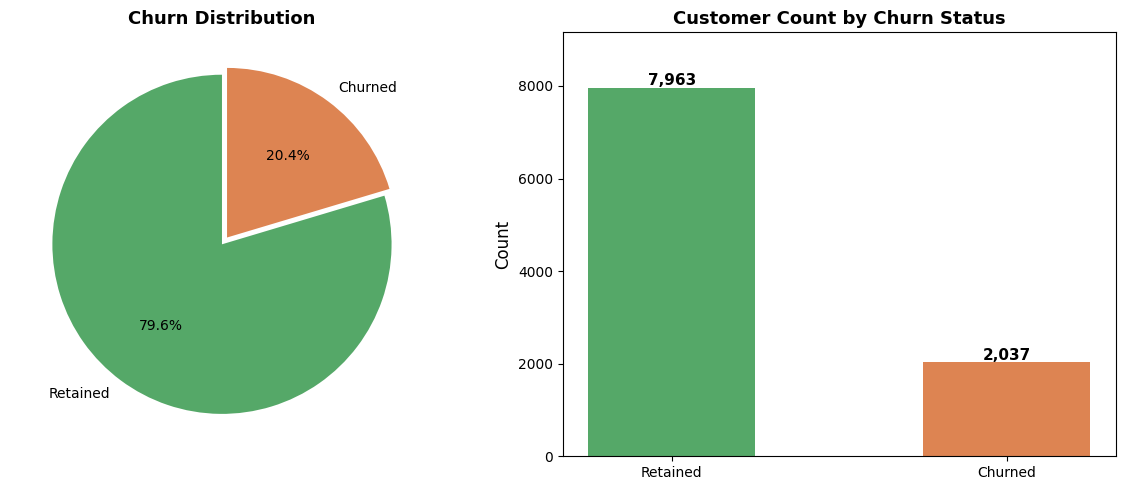

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = y.value_counts()
axes[0].pie(counts, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#55A868', '#DD8452'],
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')

axes[1].bar(['Retained', 'Churned'], counts.values, color=['#55A868', '#DD8452'], width=0.5)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

## Graph 2: Feature Distributions by Churn

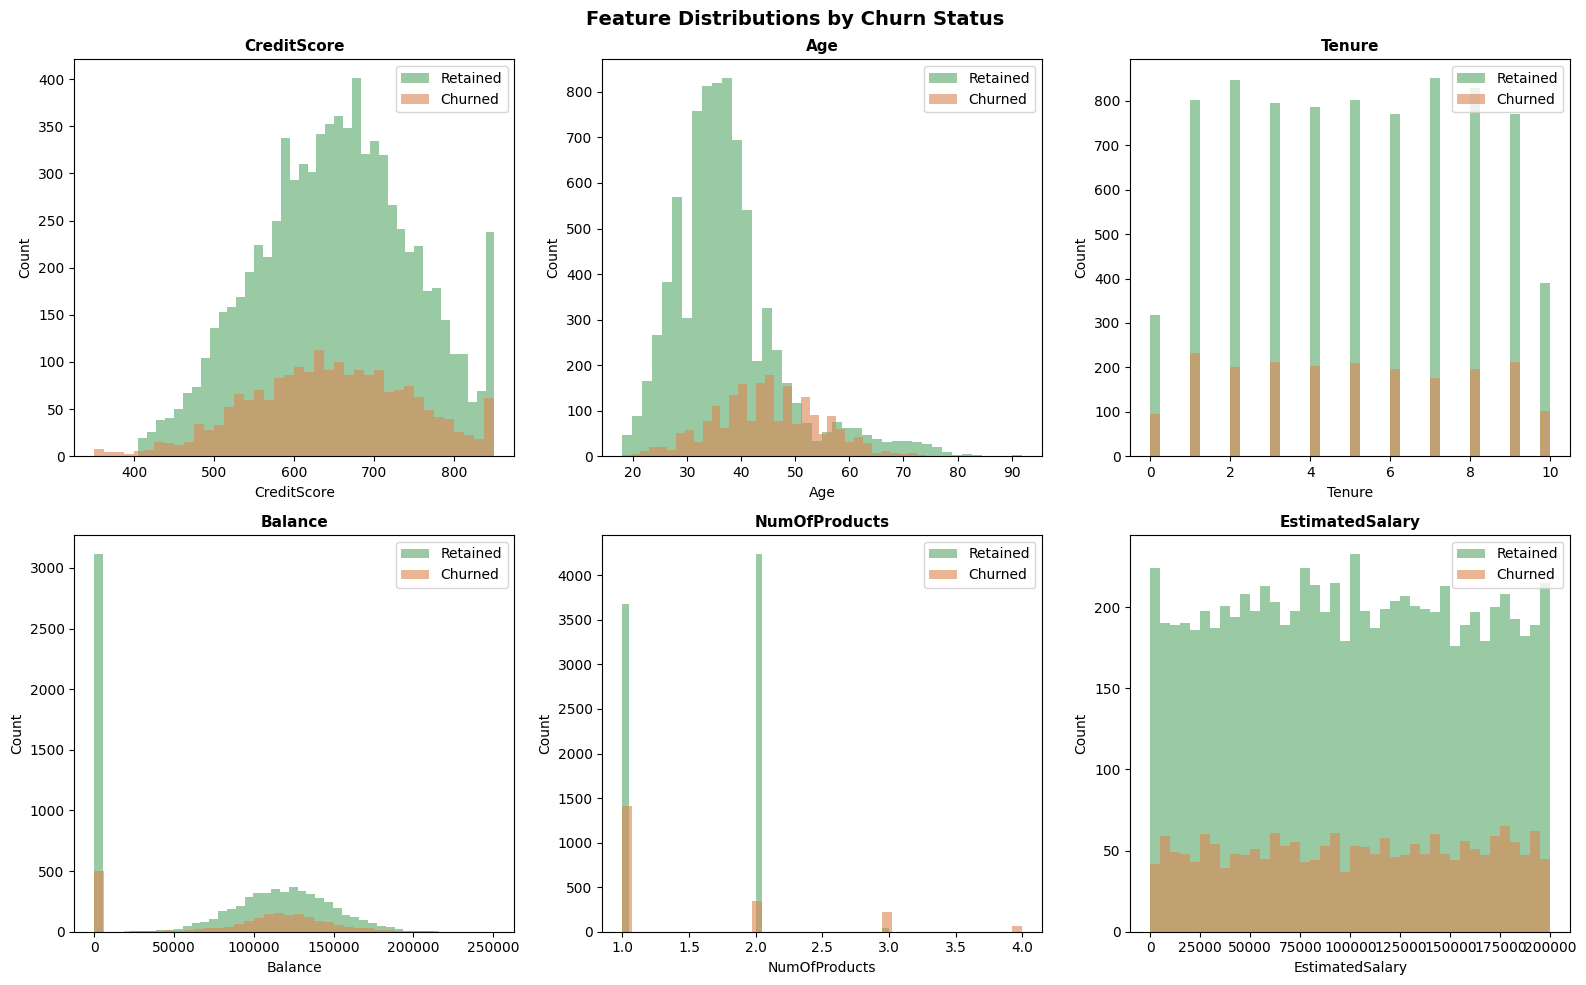

In [7]:
df_plot = df.copy()
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color in [(0, '#55A868'), (1, '#DD8452')]:
        axes[i].hist(df_plot[df_plot['Exited']==label][feat],
                     bins=40, alpha=0.6, color=color,
                     label='Retained' if label==0 else 'Churned')
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Graph 3: Model Performance Comparison

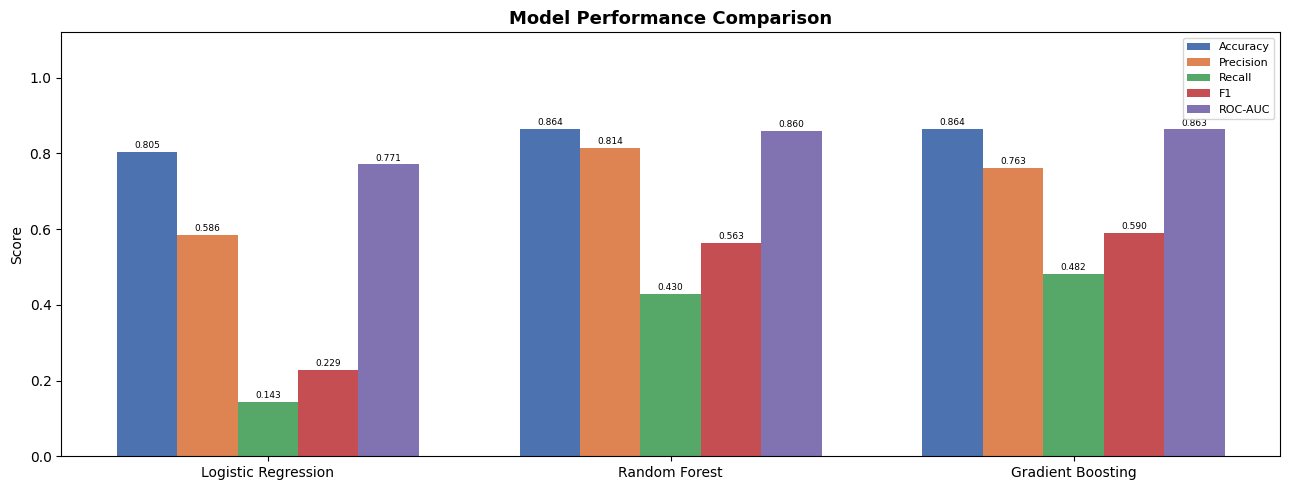

In [8]:
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics_df))
width = 0.15
metric_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (metric, color) in enumerate(zip(metric_list, colors)):
    vals  = metrics_df[metric].values
    rects = ax.bar(x + i*width, vals, width, label=metric, color=color)
    for rect in rects:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
                f'{rect.get_height():.3f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_df['Model'], fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## Graph 4: Confusion Matrix

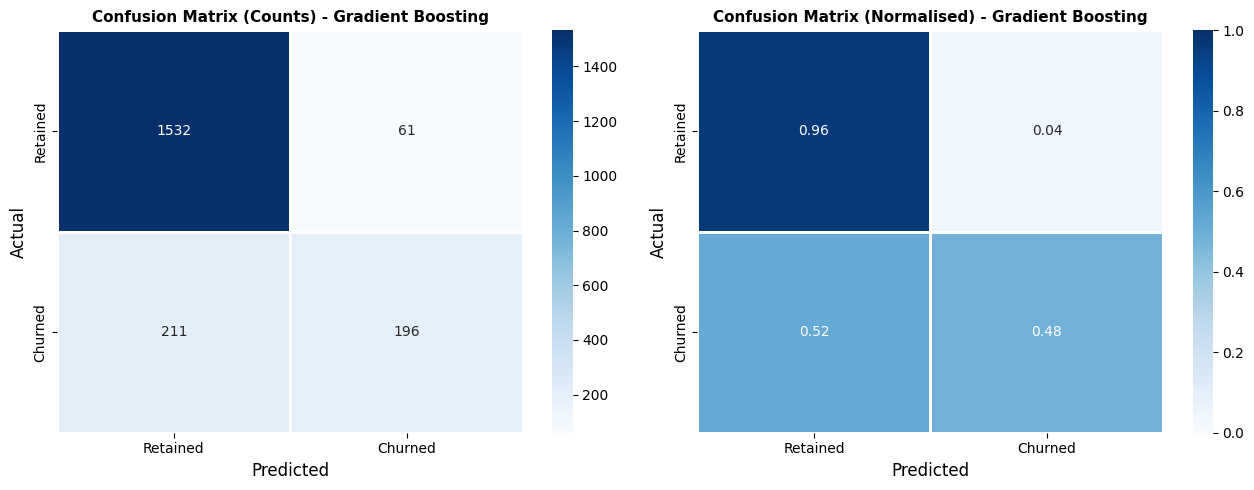

In [9]:
cm      = confusion_matrix(y_test, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix (Counts) - {best_name}', fontsize=11, fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Confusion Matrix (Normalised) - {best_name}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Graph 5: ROC Curves

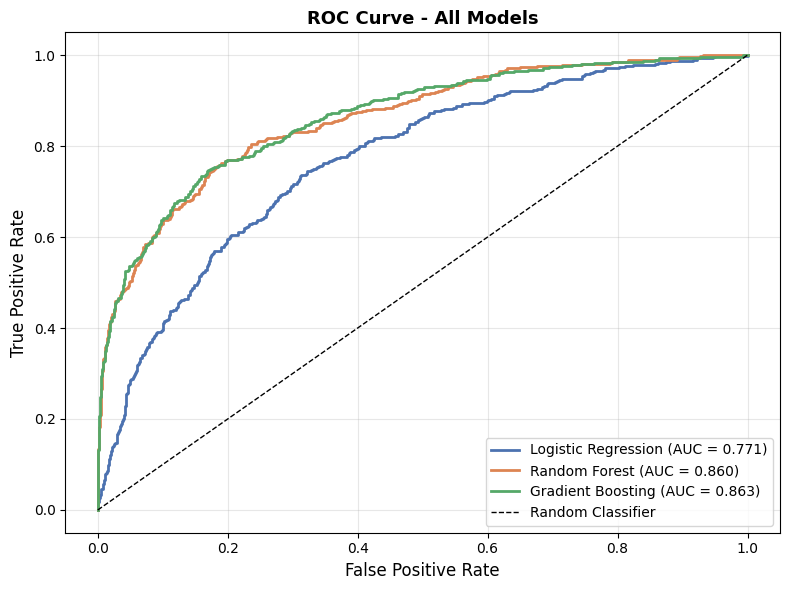

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']

for (name, (clf, Xte)), color in zip(trained.items(), colors):
    proba       = clf.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Graph 6: Feature Importance

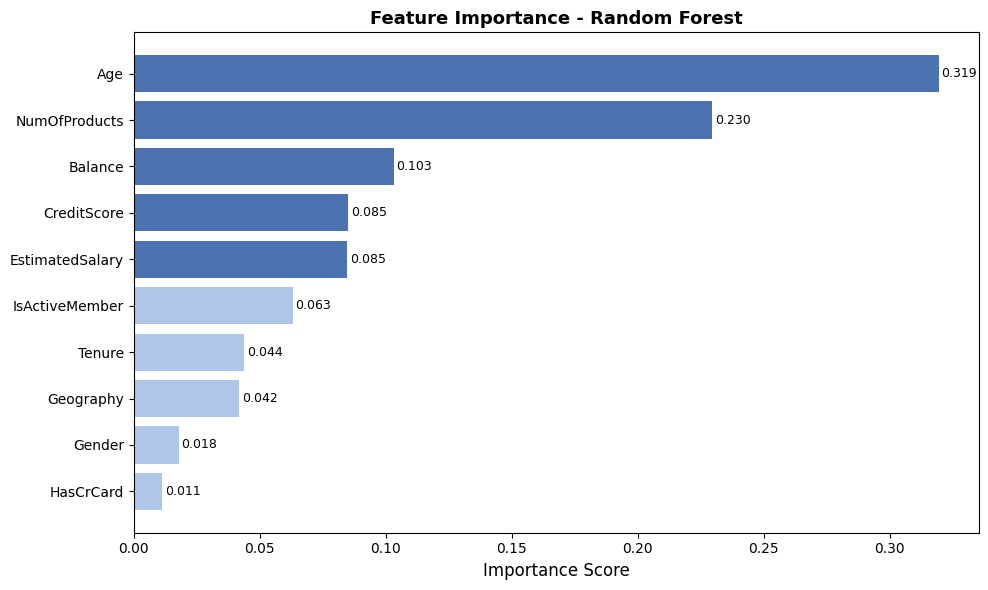

In [11]:
rf_clf        = trained['Random Forest'][0]
importances   = rf_clf.feature_importances_
feat_names    = X.columns.tolist()
feat_imp_df   = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df   = feat_imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#4C72B0' if v >= feat_imp_df['Importance'].median() else '#aec7e8'
              for v in feat_imp_df['Importance']]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors_bar)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(feat_imp_df.iterrows()):
    ax.text(row['Importance'] + 0.001, i, f"{row['Importance']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Graph 7: Correlation Heatmap

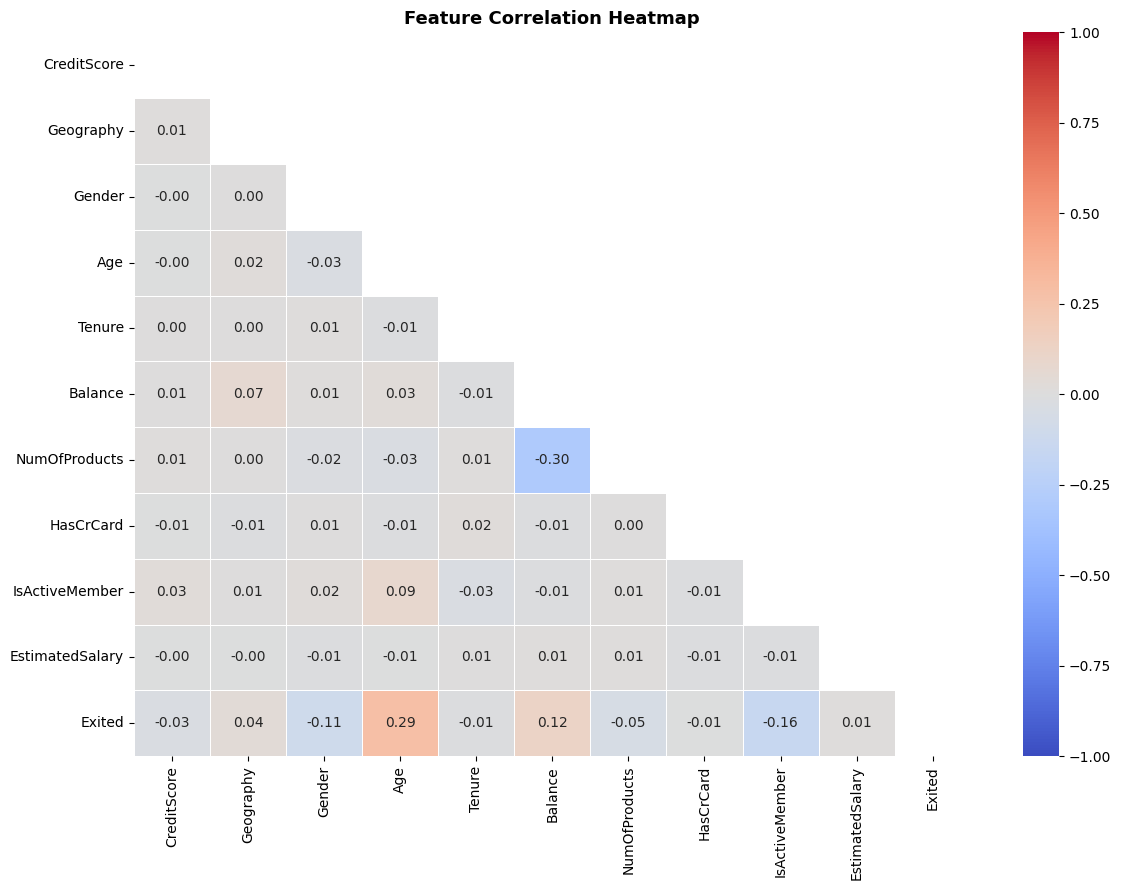

In [12]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, center=0)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Graph 8: Cross Validation Scores

Logistic Regression: mean=0.7541  std=0.0130
Random Forest: mean=0.8601  std=0.0039
Gradient Boosting: mean=0.8630  std=0.0040


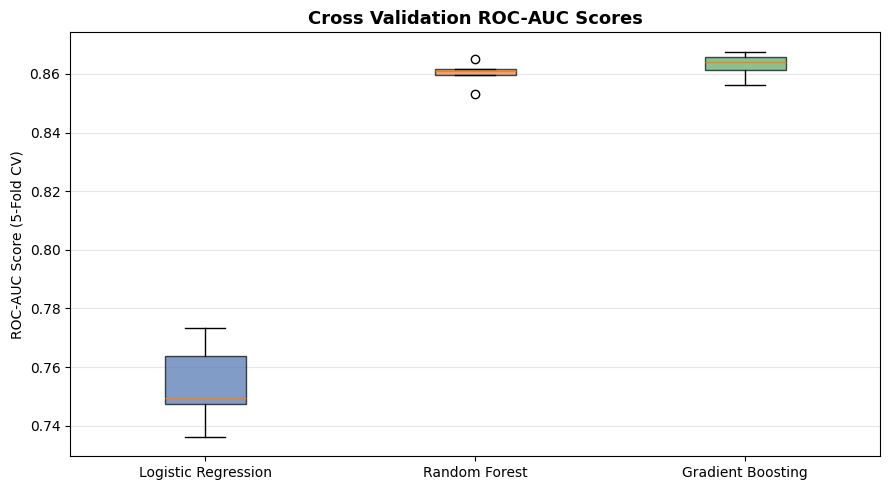

In [13]:
cv_results = {}
cv_models  = {
    'Logistic Regression': (trained['Logistic Regression'][0], X_test_scaled, X_train_scaled),
    'Random Forest':       (trained['Random Forest'][0],       X_test,        X_train),
    'Gradient Boosting':   (trained['Gradient Boosting'][0],   X_test,        X_train),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (clf, Xte, Xtr) in cv_models.items():
    scores = cross_val_score(clf, pd.concat([pd.DataFrame(Xtr), pd.DataFrame(Xte)]),
                             pd.concat([y_train, y_test]),
                             cv=skf, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name}: mean={scores.mean():.4f}  std={scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(cv_results.values(), patch_artist=True)
colors_bp = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(cv_results)+1))
ax.set_xticklabels(cv_results.keys(), fontsize=10)
ax.set_ylabel('ROC-AUC Score (5-Fold CV)')
ax.set_title('Cross Validation ROC-AUC Scores', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Predict a Single Customer

In [14]:
def predict_customer(credit_score, geography, gender, age, tenure,
                     balance, num_products, has_cr_card, is_active, salary):
    geo_enc    = le_geo.transform([geography])[0]
    gender_enc = le_gender.transform([gender])[0]
    features   = np.array([[credit_score, geo_enc, gender_enc, age, tenure,
                             balance, num_products, has_cr_card, is_active, salary]])
    clf, _     = trained['Gradient Boosting']
    prob       = clf.predict_proba(features)[0][1]
    pred       = clf.predict(features)[0]
    result     = 'LIKELY TO CHURN' if pred == 1 else 'LIKELY TO STAY'
    print(f'Churn Probability : {prob:.2%}')
    print(f'Prediction        : {result}')
    print('-' * 40)

# Example customers
print('Customer 1 - Young active member with low balance:')
predict_customer(650, 'France', 'Male', 30, 5, 0, 2, 1, 1, 50000)

print('Customer 2 - Older inactive member with high balance:')
predict_customer(500, 'Germany', 'Female', 55, 2, 120000, 1, 0, 0, 90000)

print('Customer 3 - High credit score long tenure:')
predict_customer(800, 'Spain', 'Male', 40, 9, 75000, 2, 1, 1, 110000)

Customer 1 - Young active member with low balance:
Churn Probability : 1.00%
Prediction        : LIKELY TO STAY
----------------------------------------
Customer 2 - Older inactive member with high balance:
Churn Probability : 93.61%
Prediction        : LIKELY TO CHURN
----------------------------------------
Customer 3 - High credit score long tenure:
Churn Probability : 3.44%
Prediction        : LIKELY TO STAY
----------------------------------------


## Final Summary

In [15]:
print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
for name, scores in results.items():
    marker = ' -- BEST' if name == best_name else ''
    print(f'\n{name}{marker}')
    for metric, val in scores.items():
        print(f'   {metric:<12}: {val:.4f}')
print('=' * 55)

  FINAL RESULTS SUMMARY

Logistic Regression
   Accuracy    : 0.8050
   Precision   : 0.5859
   Recall      : 0.1425
   F1          : 0.2292
   ROC-AUC     : 0.7710

Random Forest
   Accuracy    : 0.8640
   Precision   : 0.8140
   Recall      : 0.4300
   F1          : 0.5627
   ROC-AUC     : 0.8596

Gradient Boosting -- BEST
   Accuracy    : 0.8640
   Precision   : 0.7626
   Recall      : 0.4816
   F1          : 0.5904
   ROC-AUC     : 0.8633
